In [1]:
import zeus

In [2]:

import LazyEval
import allshowers
import numpy as np
import matplotlib.pyplot as plt
import showerdata
import zarr

In [3]:
import h5py as h5
import time

In [4]:
data_conditioning = "/data/dust/user/diptarko/data/showers.h5"

In [5]:
file = h5.File(data_conditioning, "r")

In [6]:
file["showers"][5]

array([-3.6136116e+01, -3.5260704e+01,  1.9000000e+01, ...,
       -7.4566779e+02,  7.7000000e+01,  1.4164904e-05],
      shape=(7076,), dtype=float32)

In [7]:
x = []
y = []
for i in [1,5,10,20,50,100,200,500,1_000,2_000,5_000,10_000,20_000,50_000,100_000,200_000,500_000]:
    time_start = time.time()

    showers_all = showerdata.load(data_conditioning,
                                stop=i
                                )
    time_end = time.time()
    x.append(i)
    y.append(time_end - time_start)
    print(f"Time taken to load {i} showers: {time_end - time_start} seconds")

Time taken to load 1 showers: 0.003802776336669922 seconds
Time taken to load 5 showers: 0.0032684803009033203 seconds
Time taken to load 10 showers: 0.003588438034057617 seconds
Time taken to load 20 showers: 0.004843473434448242 seconds
Time taken to load 50 showers: 0.010109186172485352 seconds
Time taken to load 100 showers: 0.015767335891723633 seconds
Time taken to load 200 showers: 0.024521350860595703 seconds
Time taken to load 500 showers: 0.05437469482421875 seconds
Time taken to load 1000 showers: 0.10007262229919434 seconds
Time taken to load 2000 showers: 0.19211053848266602 seconds
Time taken to load 5000 showers: 0.4736785888671875 seconds
Time taken to load 10000 showers: 1.1605570316314697 seconds
Time taken to load 20000 showers: 1.9378352165222168 seconds
Time taken to load 50000 showers: 5.1091084480285645 seconds
Time taken to load 100000 showers: 12.002302169799805 seconds
Time taken to load 200000 showers: 38.82310080528259 seconds
Time taken to load 500000 showe

In [7]:
showers_all = showerdata.load(data_conditioning,
                            stop=100)

In [8]:
showers_all.points.nbytes / (1024)

9400.0

In [9]:

showers_all.points.nbytes / (1024*1024)

9.1796875

In [10]:
showers_all = list([zeus.ZeusArray.create_zeus_array(showers_all.points[i]) for i in range(showers_all.points.shape[0])])

In [11]:
z_data = zeus.core.dataset.ZeusDataset(showers_all)

AttributeError: module 'zeus.core' has no attribute 'dataset'

In [12]:
z = zeus.core.ZeusArray.create_zeus_array(showers_all.points)
z = zeus.core.ZeusArray.compress_array(z)

In [14]:
z.nbytes / 1024

18.2890625

In [13]:
(np.array(z) == showers_all.points).all()

/tmp/ipykernel_2563334/2675321497.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  (np.array(z) == showers_all.points).all()


np.True_

In [11]:
np.all(np.array(compressed_data) == z.data)

/tmp/ipykernel_2563334/513047670.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.all(np.array(compressed_data) == z.data)


np.True_

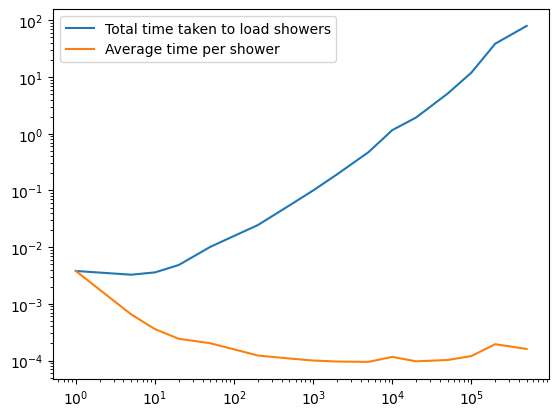

In [14]:
plt.plot(x, y, label='Total time taken to load showers')
plt.xscale('log')
plt.yscale('log')

average_time_per_shower = [time_taken / num_showers for time_taken, num_showers in zip(y, x)]

plt.plot(x, average_time_per_shower, label='Average time per shower')
plt.legend()

In [ ]:
final_average_time_per_shower = average_time_per_shower[-1]
total_number_of_showers = 2_000_000
estimated_total_time = final_average_time_per_shower * total_number_of_showers
print(f"Estimated total time to load {total_number_of_showers} showers: {estimated_total_time} seconds ({estimated_total_time / 60:.2f} mins)")

Estimated total time to load 2000000 showers: 320.3981981277466 seconds (5.34 mins)


In [ ]:
def read_from_h5(file_path, num_showers):
    with h5.File(file_path, "r") as f:
        showers = f["showers"][:num_showers]
    return showers

In [18]:
showers = read_from_h5(data_conditioning, 100)

In [20]:
x = []
y = []
for i in [1,5,10,20,50,100,200,500,1_000,2_000,5_000,10_000,20_000,50_000,100_000,200_000,500_000]:
    time_start = time.time()

    showers_all = read_from_h5(data_conditioning, i)
    time_end = time.time()
    x.append(i)
    y.append(time_end - time_start)
    print(f"Time taken to load {i} showers: {time_end - time_start} seconds")

Time taken to load 1 showers: 0.22373509407043457 seconds
Time taken to load 5 showers: 0.0014803409576416016 seconds
Time taken to load 10 showers: 0.0008401870727539062 seconds
Time taken to load 20 showers: 0.0011208057403564453 seconds
Time taken to load 50 showers: 0.0017085075378417969 seconds
Time taken to load 100 showers: 0.002969503402709961 seconds
Time taken to load 200 showers: 0.024784088134765625 seconds
Time taken to load 500 showers: 0.06819462776184082 seconds
Time taken to load 1000 showers: 0.11658930778503418 seconds
Time taken to load 2000 showers: 0.1900622844696045 seconds
Time taken to load 5000 showers: 0.46314406394958496 seconds
Time taken to load 10000 showers: 0.8983418941497803 seconds
Time taken to load 20000 showers: 1.9815962314605713 seconds
Time taken to load 50000 showers: 4.627641916275024 seconds
Time taken to load 100000 showers: 9.200645446777344 seconds
Time taken to load 200000 showers: 18.659929037094116 seconds
Time taken to load 500000 show

In [21]:
average_time_per_shower = [time_taken / num_showers for time_taken, num_showers in zip(y, x)]

In [22]:
final_average_time_per_shower = average_time_per_shower[-1]
total_number_of_showers = 2_000_000
estimated_total_time = final_average_time_per_shower * total_number_of_showers
print(f"Estimated total time to load {total_number_of_showers} showers: {estimated_total_time} seconds ({estimated_total_time / 60:.2f} mins)")

Estimated total time to load 2000000 showers: 196.6284818649292 seconds (3.28 mins)


In [103]:
x = np.array([[[1,1],[2,2],[3,3]],
              [[0,0],[0,9],[0,0]],
              [[7,7],[8,8],[9,9]]
              ])

In [104]:
mask = x !=0

In [115]:
x.shape

(3, 3, 2)

In [116]:
y = x.flatten()

In [121]:
z = np.reshape(y,shape=x.shape)

In [123]:
z

array([[[1, 1],
        [2, 2],
        [3, 3]],

       [[0, 0],
        [0, 9],
        [0, 0]],

       [[7, 7],
        [8, 8],
        [9, 9]]])

In [125]:
x

array([[[1, 1],
        [2, 2],
        [3, 3]],

       [[0, 0],
        [0, 9],
        [0, 0]],

       [[7, 7],
        [8, 8],
        [9, 9]]])

In [108]:
x[np.nonzero(x)]

array([1, 1, 2, 2, 3, 3, 9, 7, 7, 8, 8, 9, 9])

In [110]:
coord = np.nonzero(x)

In [114]:
coord

(array([0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2]),
 array([0, 0, 1, 1, 2, 2, 1, 0, 0, 1, 1, 2, 2]),
 array([0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1]))

In [111]:
y = np.zeros(x.shape)

In [112]:
y[coord] = x

ValueError: shape mismatch: value array of shape (3,3,2) could not be broadcast to indexing result of shape (13,)

In [106]:
np.argwhere(mask).shape

(13, 3)

In [99]:
x = np.zeros((10, 20, 30, 40))

x[2, 5, 7, 9] = 3.14
x[8, 1, 4, 12] = 2.71


In [100]:
mask = x != 0

coordinates = np.argwhere(mask)

In [102]:
x[coordinates].shape

IndexError: index 12 is out of bounds for axis 0 with size 10